# Student Health Condition Classification — EDA & Feature Engineering

## Project Introduction

This notebook walks through the exploratory data analysis and feature engineering that shaped the **Student Health Condition Classification** project.

**Problem statement:** given lifestyle and physiological measurements collected from students (sleep, heart rate, BMI, physical activity, diet, stress, and habits), predict their overall health condition.

**Task type:** multi-class classification.

**Target variable:** `health_condition`, with three classes — `fit`, `at-risk`, and `unhealthy`.

The goal of this notebook is not to retrain the final model (that pipeline lives in `main.py` and `src/`), but to document *why* the preprocessing, encoding, and feature engineering decisions in that pipeline were made — the reasoning a reviewer can't see just by reading the code.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)


## Load Dataset

In [2]:
df = pd.read_csv("data/train.csv")
df.head()


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## Initial Data Exploration

Before touching any missing values or engineering features, it's worth understanding the raw shape of the problem: how much data we have, what types each column is stored as, where the gaps are, and what the numeric ranges look like.

In [3]:
df.shape


(690088, 15)

In [4]:
df.dtypes


id                           int64
health_condition            object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

### Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)


,missing_count,missing_pct
stress_level,82811,12.00
sleep_duration,75999,11.01
sleep_quality,58331,8.45
calorie_expenditure,52853,7.66
water_intake,43477,6.30
physical_activity_level,36621,5.31
smoking_alcohol,28582,4.14
gender,21373,3.10
step_count,13916,2.02
bmi,13898,2.01


Every feature except `id` and the target has missing values, ranging from about 1% (`heart_rate`) to nearly 12% (`stress_level`). This spread is exactly why a single, one-size-fits-all imputation strategy wouldn't be appropriate — see the **Missing Value Analysis** section below.

### Basic Statistics

In [6]:
df.describe()


,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [7]:
df["health_condition"].value_counts()


health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

The target is heavily imbalanced: the `at-risk` class makes up roughly 86% of all records, while `fit` and `unhealthy` each account for under 10%. This imbalance directly motivated the `auto_class_weights="Balanced"` setting used in the final CatBoost model.

## Exploratory Data Analysis (EDA)

### Target Distribution

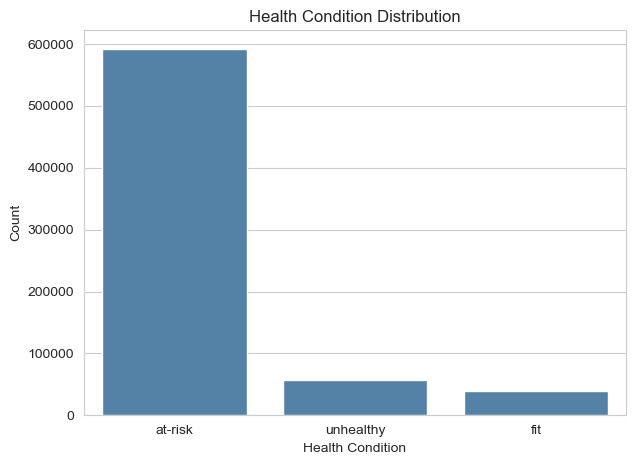

In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="health_condition", order=df["health_condition"].value_counts().index, color="steelblue")
plt.title("Health Condition Distribution")
plt.xlabel("Health Condition")
plt.ylabel("Count")
plt.show()


### Missing Values Overview

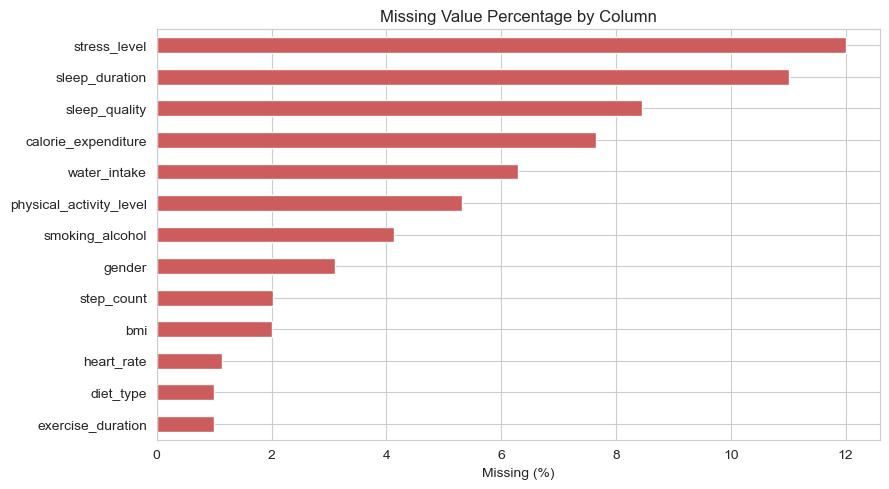

In [9]:
plt.figure(figsize=(9, 5))
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct")["missing_pct"].plot(kind="barh", color="indianred")
plt.xlabel("Missing (%)")
plt.title("Missing Value Percentage by Column")
plt.tight_layout()
plt.show()


### Sleep Duration

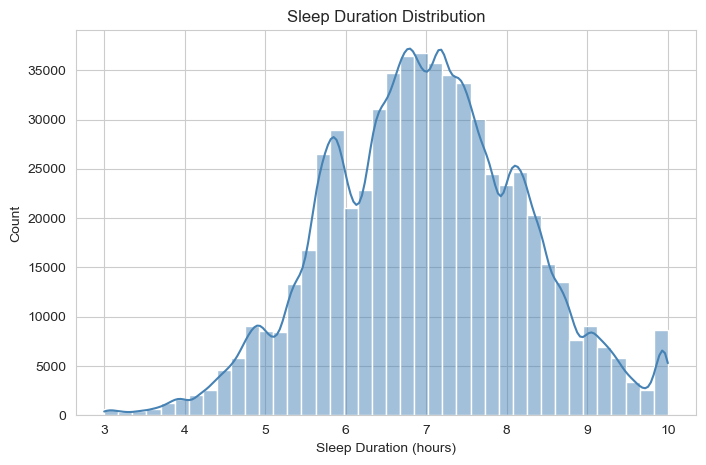

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["sleep_duration"].dropna(), bins=40, kde=True, color="steelblue")
plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Duration (hours)")
plt.show()


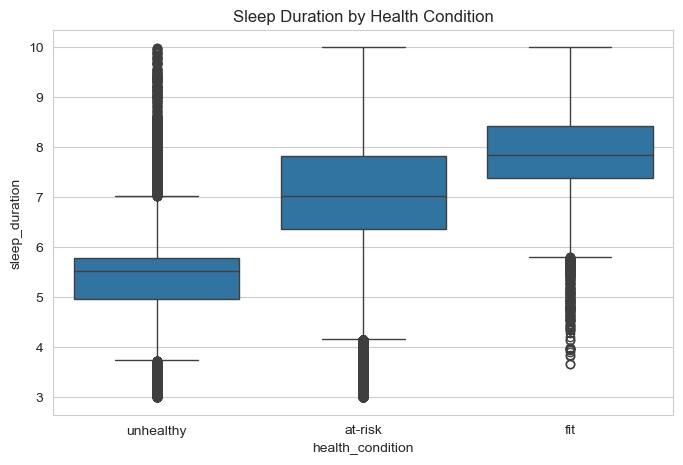

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="health_condition", y="sleep_duration")
plt.title("Sleep Duration by Health Condition")
plt.show()


Sleep duration clearly separates the classes — this is a strong early signal, and it later turns out to be the single most important feature for the model.

### BMI

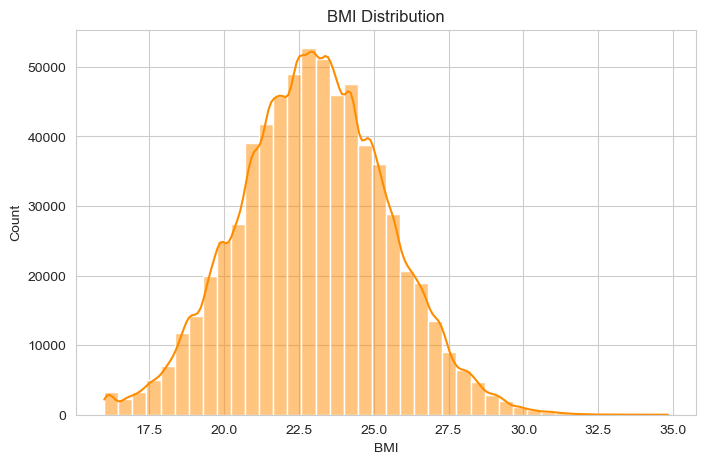

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["bmi"].dropna(), bins=40, kde=True, color="darkorange")
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.show()


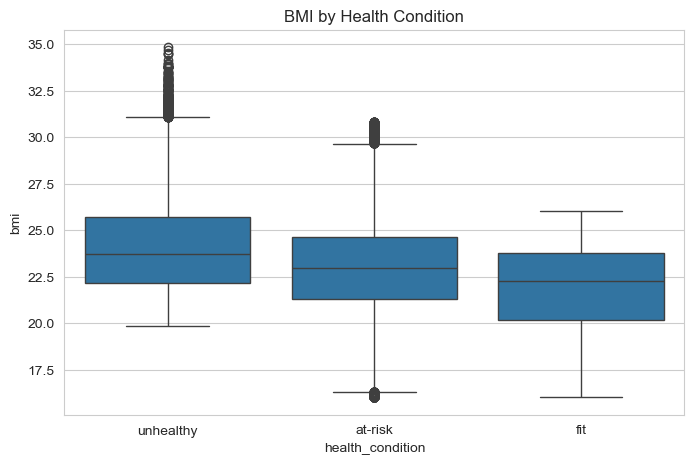

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="health_condition", y="bmi")
plt.title("BMI by Health Condition")
plt.show()


### Stress Level

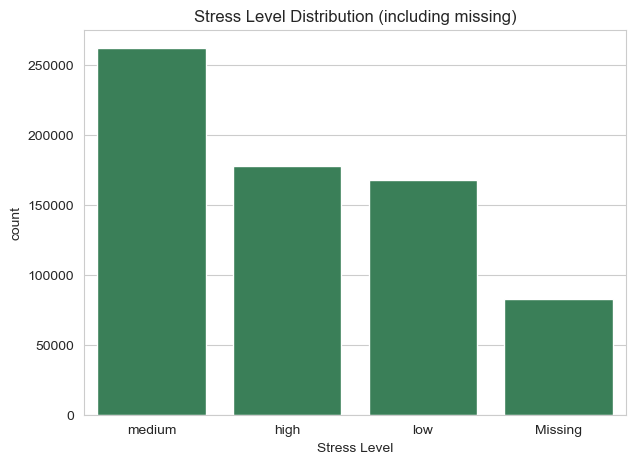

In [14]:
stress_plot_data = df["stress_level"].fillna("Missing")

plt.figure(figsize=(7, 5))
sns.countplot(
    x=stress_plot_data,
    order=stress_plot_data.value_counts().index,
    color="seagreen"
)
plt.title("Stress Level Distribution (including missing)")
plt.xlabel("Stress Level")
plt.show()


In [15]:
pd.crosstab(df["stress_level"].isna(), df["health_condition"], normalize="index") * 100


health_condition,at-risk,fit,unhealthy
stress_level,,,
False,85.863782,5.770678,8.365540
True,85.894386,5.746821,8.358793


This cross-tab is the key check behind one of the more unusual decisions in the pipeline. The *marginal* difference between the two groups is small — under half a percentage point across all three classes — so missingness alone isn't a strong standalone predictor. But `stress_level` remains the column with by far the highest missing rate (12%), and CatBoost can incorporate a preserved missingness flag at essentially no cost. Given that, the safer choice was to keep the raw signal explicit (a `stress_missing` flag, encoded stress level left as `NaN`) rather than overwrite it with an imputed mode and risk losing whatever weak signal exists — see **Encoding** below. The final feature importance results (further down) show this flag does carry a small amount of independent signal, consistent with this being a modest but real effect rather than a strong one.

### Physical Activity Level

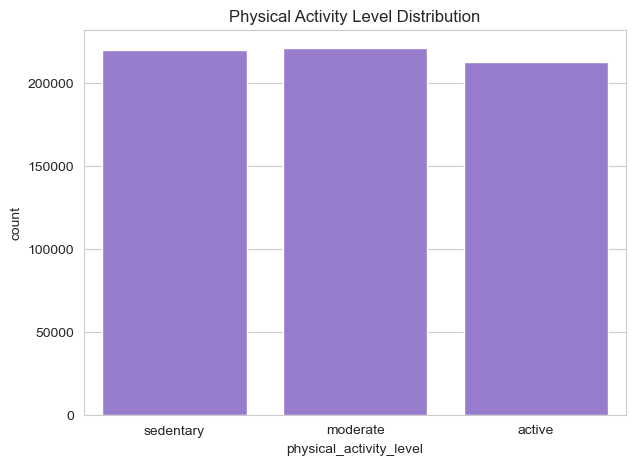

In [16]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df, x="physical_activity_level",
    order=["sedentary", "moderate", "active"],
    color="mediumpurple"
)
plt.title("Physical Activity Level Distribution")
plt.show()


### Heart Rate

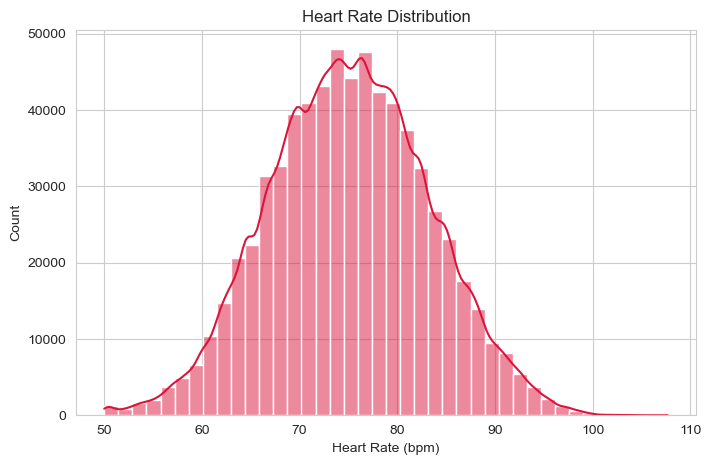

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df["heart_rate"].dropna(), bins=40, kde=True, color="crimson")
plt.title("Heart Rate Distribution")
plt.xlabel("Heart Rate (bpm)")
plt.show()


### Correlation Between Numeric Features

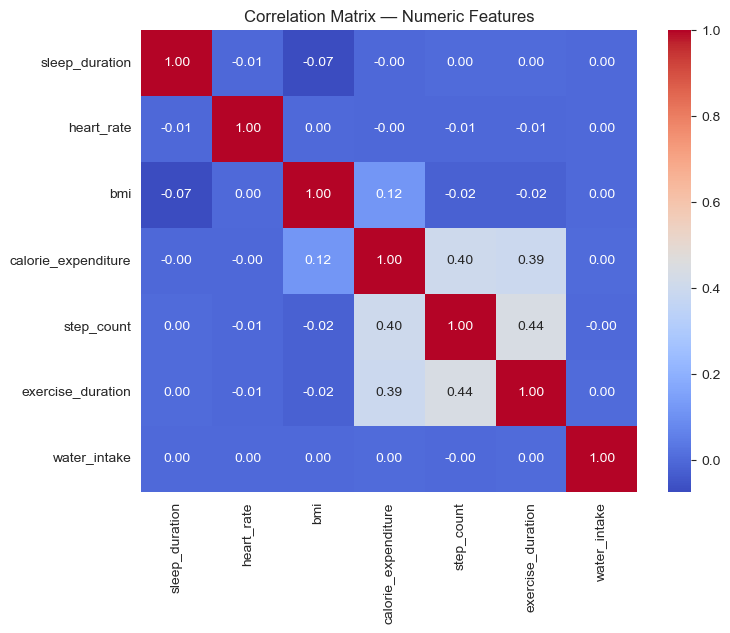

In [18]:
numeric_cols = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
                "step_count", "exercise_duration", "water_intake"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix — Numeric Features")
plt.show()


Most feature pairs show little to no linear correlation. The one exception is a moderate cluster among `step_count`, `exercise_duration`, and `calorie_expenditure` (correlations around 0.4) — which makes intuitive sense, since more steps and more exercise both drive higher calorie burn. Everything else, including `sleep_duration` and `bmi`, is essentially uncorrelated with the rest, suggesting most of the model's signal has to come from these features individually (and their interactions) rather than from redundancy between them.

## Missing Value Analysis

Every feature in this dataset has missing values, but not for the same reason or at the same rate, so a single imputation strategy would have been a poor fit. The approach taken was:

- **Columns with less than ~5% missing** (`heart_rate`, `bmi`, `step_count`, `exercise_duration`, `diet_type`, `smoking_alcohol`, `gender`): imputed with `SimpleImputer`, using the mean for numeric columns whose mean and median were close, and the most frequent category for categorical columns. At this missing rate, a simple statistic is unlikely to distort the distribution, and it's cheap to compute.
- **Columns with more than ~5% missing** (`sleep_duration`, `sleep_quality`, `physical_activity_level`, `calorie_expenditure`, `water_intake`): imputed with `KNNImputer` on standardized data. At higher missing rates, a single global statistic risks flattening real variation between students, while KNN borrows information from the *most similar* students, which better preserves the underlying distribution.
- **`stress_level`**: the one exception. As shown above, missingness in this column correlates with the target itself, so filling it with the mode would have destroyed a real signal. Instead, missingness was preserved explicitly (see **Encoding**).

Class-conditional imputation (filling values based on the target class) was considered and rejected: feature means were nearly identical across the three health-condition classes, so grouping by target before imputing added complexity without adding information.

## Encoding

Two categorical features carry a natural order, and encoding them as such lets the model use that ranking directly instead of treating the categories as unrelated:

- `sleep_quality`: `poor` < `average` < `good` → `0`, `1`, `2`
- `physical_activity_level`: `sedentary` < `moderate` < `active` → `0`, `1`, `2`
- `stress_level`: `low` < `medium` < `high` → `0`, `1`, `2`

`stress_level` gets special treatment on top of the ordinal mapping. Before encoding, a binary flag `stress_missing` is created to capture whether the value was originally missing. The category is then ordinally mapped, and — unlike every other column — the resulting missing values are deliberately **left as `NaN`** rather than imputed. CatBoost handles missing numeric values natively, so the model can use both the ordinal relationship of the observed stress levels *and* the fact that a value was missing in the first place, without losing either signal.

Nominal categorical features without a natural order (`diet_type`, `smoking_alcohol`, `gender`) are passed to CatBoost as-is via `cat_features`, letting the model handle the encoding internally rather than expanding them with one-hot encoding.

In [19]:
sleep_map = {"poor": 0, "average": 1, "good": 2}
physical_map = {"sedentary": 0, "moderate": 1, "active": 2}
stress_map = {"low": 0, "medium": 1, "high": 2}

demo = df[["sleep_quality", "physical_activity_level", "stress_level"]].head()
demo.assign(
    sleep_quality_enc=demo["sleep_quality"].map(sleep_map),
    physical_activity_level_enc=demo["physical_activity_level"].map(physical_map),
    stress_level_enc=demo["stress_level"].map(stress_map),
)


,sleep_quality,physical_activity_level,stress_level,sleep_quality_enc,physical_activity_level_enc,stress_level_enc
0,average,sedentary,high,1,0,2.0
1,average,moderate,low,1,1,0.0
2,poor,active,high,0,2,2.0
3,average,active,high,1,2,2.0
4,average,sedentary,NaN,1,0,NaN


## Feature Engineering

More than 30 interaction features were designed and tested during development — combinations of sleep, stress, and activity levels, categorical sleep-duration buckets, and various flag features marking specific lifestyle combinations (e.g. low sleep *and* high stress). Each candidate was evaluated by its effect on validation F1/balanced accuracy rather than intuition alone.

Most of these did not survive: they either didn't move the validation score or slightly hurt it, likely by adding noise or overlapping with information CatBoost could already extract from the raw features. Only interaction features that gave a **consistent** improvement across validation runs were kept in the final pipeline.

The one that mattered most was `stress_exercise` — the ratio of encoded stress level to exercise duration. It captures a combined lifestyle pattern (high stress, low exercise) that neither raw feature expresses on its own, and it was the single interaction feature with the clearest positive impact on the model.

In [20]:
demo = df[["stress_level", "exercise_duration"]].dropna().head()
stress_encoded = demo["stress_level"].map(stress_map)

demo.assign(
    stress_level_encoded=stress_encoded,
    stress_exercise=(stress_encoded + 1) / (demo["exercise_duration"] + 1)
)


,stress_level,exercise_duration,stress_level_encoded,stress_exercise
0,high,19.8,2,0.144231
1,low,49.9,0,0.019646
2,high,38.1,2,0.076726
3,high,59.9,2,0.049261
5,low,29.2,0,0.033113


This is the same formula used in `src/feature_engineering.py`; it's reproduced here only to illustrate the idea, not to duplicate the pipeline.

## Feature Importance

Feature importance from the final trained CatBoost model (computed in `main.py`), shown here for reference.

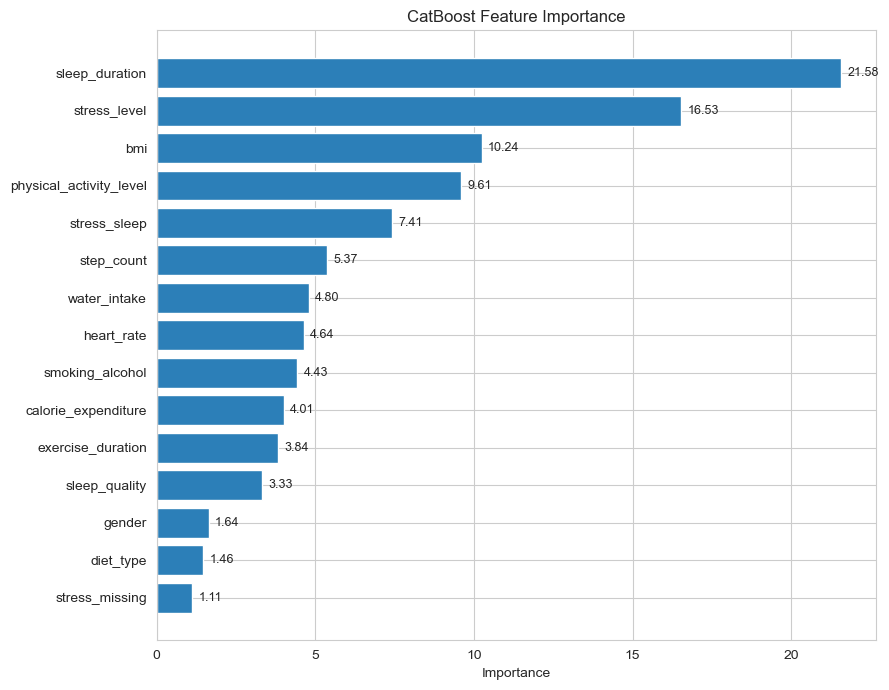

In [21]:
importance = pd.DataFrame({
    "feature": ["sleep_duration", "stress_level", "bmi", "physical_activity_level",
                "stress_sleep", "step_count", "water_intake", "heart_rate",
                "smoking_alcohol", "calorie_expenditure", "exercise_duration",
                "sleep_quality", "gender", "diet_type", "stress_missing"],
    "importance": [21.581411, 16.528541, 10.243161, 9.605405, 7.406135,
                   5.372013, 4.796374, 4.643653, 4.434527, 4.005120,
                   3.836301, 3.329915, 1.640585, 1.463639, 1.113218]
}).sort_values("importance", ascending=True)

plt.figure(figsize=(9, 7))
bars = plt.barh(importance["feature"], importance["importance"], color="#2c7fb8")
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
for bar, val in zip(bars, importance["importance"]):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, f"{val:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


`sleep_duration` and `stress_level` are, by a clear margin, the two strongest predictors — together accounting for roughly 38% of total importance. `bmi` and `physical_activity_level` follow, and the engineered `stress_sleep` interaction ranks fifth, ahead of several raw features. This confirms that the most useful signal in this dataset is largely about sleep and stress, with body composition and activity level as secondary factors.

## Model Selection

**CatBoost** was chosen as the final model for a few concrete reasons:

- It natively handles the categorical features (`diet_type`, `smoking_alcohol`, `gender`) without manual encoding.
- It natively handles missing numeric values, which was essential for preserving the `stress_level` missingness signal described above.
- It showed the strongest and most consistent validation performance among the models tried during development.
- It generalized better to the validation set than the alternatives, with less evidence of overfitting.

The full training pipeline — data loading, final feature engineering, model configuration, and evaluation — is implemented in `main.py`. This notebook does not retrain the model; it exists purely to document the analysis and reasoning that led to that pipeline's design.

## Kaggle Results

Final public leaderboard score: **Balanced Accuracy = 0.94917**

This result was achieved with a single CatBoost model built on carefully engineered features, rather than ensembling or leaderboard-specific tuning.

## Conclusion

This project predicts student health condition from lifestyle and physiological data using a single, well-tuned CatBoost model. The main drivers of performance were:

- Missing-value strategies matched to each column's missing rate and pattern, rather than a uniform approach.
- Recognizing that `stress_level`'s missingness itself was informative, and preserving that signal instead of imputing it away.
- Testing a large number of interaction features and keeping only the small subset that reliably improved validation performance.

**Possible future improvements:**

- Hyperparameter optimization with **Optuna**
- Model explainability with **SHAP**
- Automated search for feature interactions, rather than manual trial and error
- Comparison against tabular foundation models such as **TabPFN**